In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
orders = pd.read_csv("../data/processed/shopee_orders_thailand.csv")
order_items = pd.read_csv("../data/processed/shopee_order_items_thailand.csv")
customers = pd.read_csv("../data/processed/shopee_customers_thailand.csv")
products = pd.read_csv("../data/processed/shopee_products_thailand.csv")
product_campaigns = pd.read_csv("../data/processed/shopee_product_campaign_thailand.csv")
sellers = pd.read_csv("../data/processed/shopee_sellers_thailand.csv")
campaigns = pd.read_csv("../data/processed/shopee_campaigns_thailand.csv")
shipments = pd.read_csv("../data/processed/shopee_shipments_thailand.csv")

c:\Users\Maay\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
21:34:07 - cmdstanpy - INFO - Chain [1] start processing
21:34:07 - cmdstanpy - INFO - Chain [1] done processing


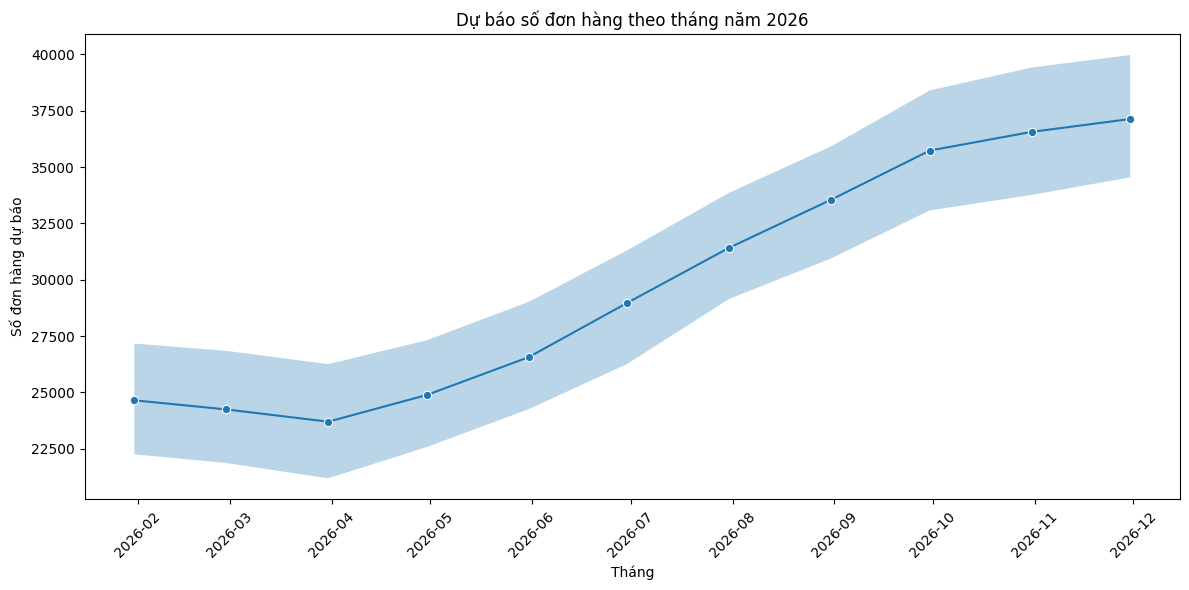

In [2]:
#dự đoán xu hướng
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['year_month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()

orders_by_month = (
    orders.groupby('year_month')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'year_month':'ds','order_id':'y'})
)

model = Prophet()
model.fit(orders_by_month)

future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)

forecast_2026 = forecast[forecast['ds'].dt.year == 2026]

plt.figure(figsize=(12,6))
sns.lineplot(data=forecast_2026, x="ds", y="yhat", marker="o")
plt.fill_between(forecast_2026['ds'],
                 forecast_2026['yhat_lower'],
                 forecast_2026['yhat_upper'],
                 alpha=0.3)

plt.title("Dự báo số đơn hàng theo tháng năm 2026")
plt.xlabel("Tháng")
plt.ylabel("Số đơn hàng dự báo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
# GNN RECOMMEND PRODUCT
import torch
import pandas as pd
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

# ===== 0. Merge data =====
df = order_items.merge(orders, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(customers, on='customer_id')

# ===== 1. Encode ID =====
df['user_id'] = df['customer_id'].astype('category').cat.codes
df['item_id'] = df['product_id'].astype('category').cat.codes

df['user_id'] = df['user_id'].astype('int64')
df['item_id'] = df['item_id'].astype('int64')

num_users = df['user_id'].nunique()
num_items = df['item_id'].nunique()

# offset item node
df['item_id'] = df['item_id'] + num_users

# remove duplicate interactions
df = df.drop_duplicates(['user_id','item_id'])

edge_index = torch.tensor([
    df['user_id'].values,
    df['item_id'].values
], dtype=torch.long)

# bidirectional graph
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

num_nodes = num_users + num_items
data = Data(edge_index=edge_index, num_nodes=num_nodes)

# ===== 3. Model =====
class GNN(torch.nn.Module):
    def __init__(self, num_nodes, hidden=64):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_nodes, hidden)
        self.conv1 = GCNConv(hidden, hidden)
        self.conv2 = GCNConv(hidden, hidden)

    def forward(self, data):
        x = self.embedding.weight
        x = self.conv1(x, data.edge_index)
        x = F.relu(x)
        x = self.conv2(x, data.edge_index)
        return x

model = GNN(num_nodes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ===== 4. Train =====
for epoch in range(50):
    model.train()
    optimizer.zero_grad()

    emb = model(data)

    user_idx = torch.tensor(df['user_id'].values, dtype=torch.long)
    item_idx = torch.tensor(df['item_id'].values, dtype=torch.long)

    user_emb = emb[user_idx]
    item_emb = emb[item_idx]

    # negative sampling
    neg_item = torch.randint(num_users, num_users + num_items, (len(df),))
    neg_emb = emb[neg_item]

    pos_score = (user_emb * item_emb).sum(dim=1)
    neg_score = (user_emb * neg_emb).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score - neg_score)).mean()

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# ===== 5. Recommend =====
model.eval()
emb = model(data)

user_id = 0
user_emb = emb[user_id]

user_idx = torch.tensor(df['user_id'].values, dtype=torch.long)
item_idx = torch.tensor(df['item_id'].values, dtype=torch.long)

user_emb = emb[user_id]
item_emb = emb[item_id]
scores = torch.matmul(emb, user_emb)

# chỉ lấy item
scores = scores[num_users:]

# remove item đã mua
purchased = df[df['user_id'] == user_id]['item_id'].values - num_users
scores[purchased] = -1e9

# top K
top_k = torch.topk(scores, 10)

# map về product_id thật
item_map = dict(enumerate(df['product_id'].astype('category').cat.categories))
recommended_items = [item_map[i.item()] for i in top_k.indices]

print("Top recommended products:", recommended_items)

C:\Users\Maay\AppData\Local\Temp\ipykernel_65076\3528416929.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([


Epoch 0, Loss: 0.5698
Epoch 10, Loss: 0.4494
Epoch 20, Loss: 0.4265
Epoch 30, Loss: 0.3878
Epoch 40, Loss: 0.3274


NameError: name 'item_id' is not defined